In [1]:
#Predict telecom customer monthly bill using Linear Regression

In [2]:
#We want to predict:
#Monthly Bill Amount
#based on:
#Data Usage
#Call Minutes
#SMS Count

In [3]:
!pip install numpy

In [4]:
#import all the libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [5]:
#read dataset
data=pd.read_csv("telecom_bill_dataset.csv")
data

,Customer_ID,Data_Usage_GB,Call_Minutes,SMS_Count,Favorite_Color,Random_Score,Monthly_Bill
0,1001,5,200,50,Red,13,320
1,1002,8,300,65,Blue,47,410
2,1003,12,450,80,Green,22,540
3,1004,15,500,90,Yellow,39,610
4,1005,18,650,100,Blue,18,720
5,1006,20,700,120,Red,56,790
6,1007,25,850,130,Green,29,920
7,1008,7,250,60,Yellow,74,390
8,1009,10,350,75,Blue,31,470
9,1010,14,480,85,Red,62,590


In [7]:
data.head()

,Customer_ID,Data_Usage_GB,Call_Minutes,SMS_Count,Favorite_Color,Random_Score,Monthly_Bill
0,1001,5,200,50,Red,13,320
1,1002,8,300,65,Blue,47,410
2,1003,12,450,80,Green,22,540
3,1004,15,500,90,Yellow,39,610
4,1005,18,650,100,Blue,18,720


In [8]:
data.tail()

,Customer_ID,Data_Usage_GB,Call_Minutes,SMS_Count,Favorite_Color,Random_Score,Monthly_Bill
15,1016,17,600,98,Yellow,68,690
16,1017,19,670,110,Blue,24,760
17,1018,23,800,128,Red,59,880
18,1019,11,420,78,Green,12,510
19,1020,21,750,118,Yellow,46,820


In [10]:
data.describe()

,Customer_ID,Data_Usage_GB,Call_Minutes,SMS_Count,Random_Score,Monthly_Bill
count,20.00000,20.000000,20.000000,20.000000,20.00000,20.000000
mean,1010.50000,14.550000,515.500000,90.700000,39.85000,613.500000
std,5.91608,6.004165,203.352818,24.963342,18.11738,185.848693
min,1001.00000,5.000000,200.000000,50.000000,12.00000,320.000000
25%,1005.75000,9.750000,345.000000,73.750000,26.25000,460.000000
50%,1010.50000,14.500000,490.000000,87.500000,39.50000,600.000000
75%,1015.25000,19.250000,677.500000,112.000000,52.25000,767.500000
max,1020.00000,25.000000,850.000000,130.000000,74.00000,920.000000


In [11]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Customer_ID     20 non-null     int64 
 1   Data_Usage_GB   20 non-null     int64 
 2   Call_Minutes    20 non-null     int64 
 3   SMS_Count       20 non-null     int64 
 4   Favorite_Color  20 non-null     object
 5   Random_Score    20 non-null     int64 
 6   Monthly_Bill    20 non-null     int64 
dtypes: int64(6), object(1)
memory usage: 1.2+ KB


In [15]:
data.describe(include='O')

,Favorite_Color
count,20
unique,4
top,Red
freq,5


In [19]:
#null value checking
data.isnull().sum()

Customer_ID       0
Data_Usage_GB     0
Call_Minutes      0
SMS_Count         0
Favorite_Color    0
Random_Score      0
Monthly_Bill      0
dtype: int64

In [21]:
#checking duplicates
data.duplicated().sum()

np.int64(0)

In [22]:
#checkibg the correlation to check how strongly the features are connected to the target var
data.corr(numeric_only=True)

,Customer_ID,Data_Usage_GB,Call_Minutes,SMS_Count,Random_Score,Monthly_Bill
Customer_ID,1.000000,0.310416,0.323957,0.328580,0.158851,0.321439
Data_Usage_GB,0.310416,1.000000,0.997465,0.993154,0.217073,0.999059
Call_Minutes,0.323957,0.997465,1.000000,0.992867,0.191378,0.998400
SMS_Count,0.328580,0.993154,0.992867,1.000000,0.232988,0.994694
Random_Score,0.158851,0.217073,0.191378,0.232988,1.000000,0.222596
Monthly_Bill,0.321439,0.999059,0.998400,0.994694,0.222596,1.000000


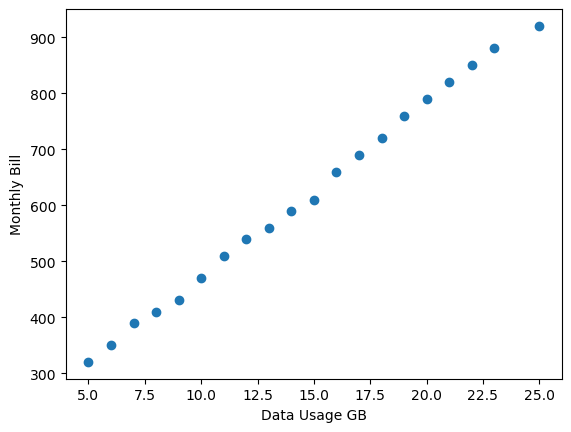

In [30]:
#visualization using scatter plot, data usage and monthly bill
plt.scatter(data['Data_Usage_GB'], data['Monthly_Bill'])
plt.xlabel("Data Usage GB")
plt.ylabel("Monthly Bill")
plt.show()

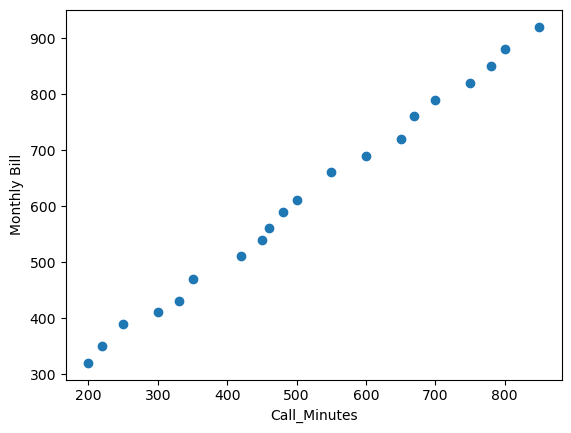

In [32]:
plt.scatter(data['Call_Minutes'], data['Monthly_Bill'])
plt.xlabel("Call_Minutes")
plt.ylabel("Monthly Bill")
plt.show()

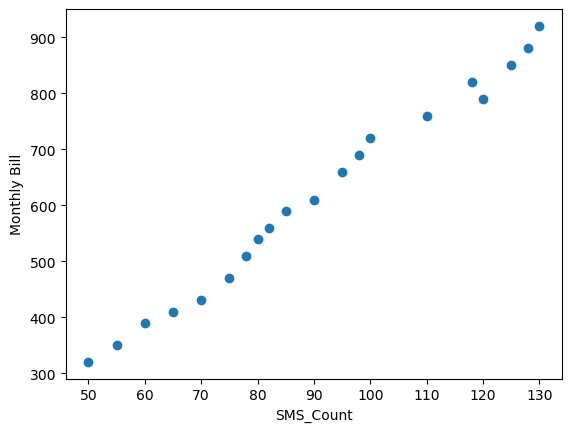

In [33]:
plt.scatter(data['SMS_Count'], data['Monthly_Bill'])
plt.xlabel("SMS_Count")
plt.ylabel("Monthly Bill")
plt.show()

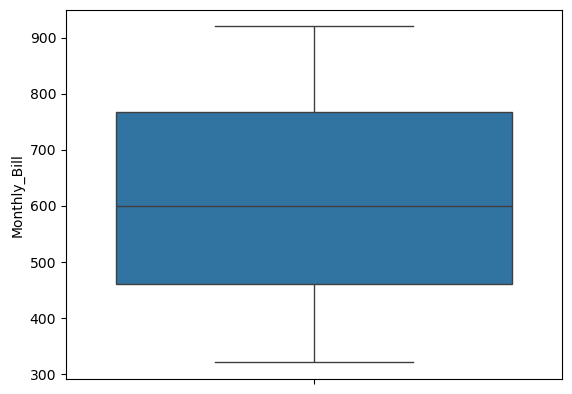

In [34]:
sns.boxplot(data['Monthly_Bill'])
plt.show()

In [42]:
#removing the irelevant features, as i checked the correlation with monthly bill and its very weak
data.drop(columns=['Customer_ID', 'Random_Score', 'Favorite_Color'], inplace=True)


KeyError: "['Customer_ID', 'Random_Score', 'Favorite_Color'] not found in axis"

In [43]:
data

,Data_Usage_GB,Call_Minutes,SMS_Count,Monthly_Bill
0,5,200,50,320
1,8,300,65,410
2,12,450,80,540
3,15,500,90,610
4,18,650,100,720
5,20,700,120,790
6,25,850,130,920
7,7,250,60,390
8,10,350,75,470
9,14,480,85,590


In [44]:
#seperate features and target
X=data.drop('Monthly_Bill',axis=1)
y = data['Monthly_Bill']

In [45]:
X

,Data_Usage_GB,Call_Minutes,SMS_Count
0,5,200,50
1,8,300,65
2,12,450,80
3,15,500,90
4,18,650,100
5,20,700,120
6,25,850,130
7,7,250,60
8,10,350,75
9,14,480,85


In [47]:
y

0     320
1     410
2     540
3     610
4     720
5     790
6     920
7     390
8     470
9     590
10    660
11    850
12    350
13    430
14    560
15    690
16    760
17    880
18    510
19    820
Name: Monthly_Bill, dtype: int64

In [48]:
print(X.head())

   Data_Usage_GB  Call_Minutes  SMS_Count
0              5           200         50
1              8           300         65
2             12           450         80
3             15           500         90
4             18           650        100


In [49]:
print(y.head())

0    320
1    410
2    540
3    610
4    720
Name: Monthly_Bill, dtype: int64


In [51]:
#Import train_test_split,Split X and y
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [53]:
#check the split
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(16, 3)
(4, 3)
(16,)
(4,)


In [54]:
#Train the linear regression,import linear regression
from sklearn.linear_model import LinearRegression

In [55]:
#model creation
model=LinearRegression()

In [57]:
#Train the model
model.fit(X_train, y_train)

LinearRegression()

In [59]:
#check the coefficient and intercept
print(model.coef_)
print(model.intercept_)

[16.89825708  0.28944844  1.0038128 ]
127.20857523594884


In [61]:
#make the prediction on test data
y_pred = model.predict(X_test)
y_pred

array([319.78018805, 875.91527625, 686.52166232, 414.47699501])

In [62]:
#Compare actual vs predicted
comparison = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred
})
print(comparison)

    Actual   Predicted
0      320  319.780188
17     880  875.915276
15     690  686.521662
1      410  414.476995


In [63]:
'''
After training the model, 
I used predict() on the test dataset to generate predicted monthly bill values 
and compared them with actual values to assess prediction accuracy.'''

'\nAfter training the model, \nI used predict() on the test dataset to generate predicted monthly bill values \nand compared them with actual values to assess prediction accuracy.'

In [66]:
#Evaluate the model performance
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("R2 Score:", r2)

MAE: 3.0649670967757885
MSE: 12.218900677479645
R2 Score: 0.9997537753012095


In [ ]:
'''
he model performed very well, achieving an R² score of 0.9997,
which indicates that the selected telecom usage features explain 
almost all the variation in monthly billing.
The low MAE and MSE values also show that prediction errors were minimal.'''